In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [15]:
x = torch.tensor([[1.0],[2.0],[3.0],[4.0],[5.0]], dtype=torch.float32)
y = torch.tensor([[3.0],[6.0],[9.0],[12.0],[15.0]], dtype=torch.float32)

In [16]:
model = nn.Linear(in_features=1, out_features=1)

In [17]:
print(f'веса {model.weight.item():.4f}, биас {model.bias.item():.4f}')

веса 0.6417, биас 0.3089


In [18]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)
loss_history = []

In [34]:
for epoch in range(100):
    y_pred = model(x)
    loss = criterion(y_pred, y)
    loss_history.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'epoch {epoch+1}/100, loss {loss.item():.4f}')

epoch 10/100, loss 0.0001
epoch 20/100, loss 0.0001
epoch 30/100, loss 0.0001
epoch 40/100, loss 0.0001
epoch 50/100, loss 0.0001
epoch 60/100, loss 0.0001
epoch 70/100, loss 0.0001
epoch 80/100, loss 0.0000
epoch 90/100, loss 0.0000
epoch 100/100, loss 0.0000


In [20]:
print(f'веса {model.weight.item():.4f}, биас {model.bias.item():.4f}')

веса 2.8236, биас 0.6368


In [21]:
custom_pred_value = 1

In [22]:
with torch.no_grad():
    predicted = model(torch.tensor([[custom_pred_value]], dtype=torch.float32))
    print(f'предсказание {predicted.item():.4f}')

предсказание 3.4605


In [11]:
def resetW(m):
    m.reset_parameters()

model.apply(resetW)
loss_history = []

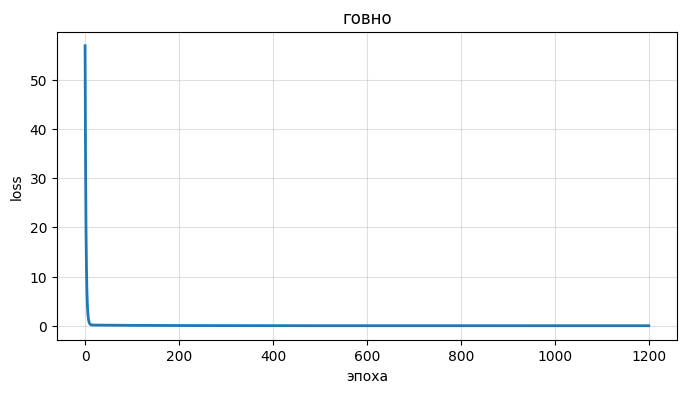

In [35]:
plt.figure(figsize=(8,4))
plt.plot(loss_history, linewidth = 2)
plt.xlabel('эпоха')
plt.ylabel('loss')
plt.title('говно')
plt.grid(True, alpha=0.4)
plt.show()

In [36]:
isAv = torch.cuda.is_available()
print(isAv)
print(torch.__version__)

True
2.10.0+cu130
